In [54]:
import numpy as np
import pandas as pd
import hdbscan

In [55]:
df = pd.read_csv(r"dataset\preprocessing\prePro-news_balanced.csv")
embeddings = np.load(r"dataset\fineTuned\embeddings\balanced_episode_embeddings.npy")
df['timestamp'] = pd.to_datetime(df['published_date'])

print("Embeddings Shape:", embeddings.shape)

Embeddings Shape: (1291, 385)


## Episode Discovery using HDBSCAN

In [56]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=8,
    min_samples=3,
    metric='euclidean'
)

labels = clusterer.fit_predict(embeddings)

print("Unique Clusters:", np.unique(labels))

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Unique Clusters: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [57]:
df['episode'] = labels

print(df['episode'].value_counts())

-1     713
 18    162
 13     46
 3      42
 8      38
 14     34
 0      33
 11     26
 2      24
 9      21
 12     20
 20     19
 15     17
 4      17
 7      12
 19     11
 16     11
 10     11
 6       9
 5       9
 17      8
 1       8
Name: episode, dtype: int64


## Dimentionality Reduction

In [58]:
import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

embedding_2d = reducer.fit_transform(embeddings)

print("UMAP Shape:", embedding_2d.shape)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP Shape: (1291, 2)


## Episode cluster visualization

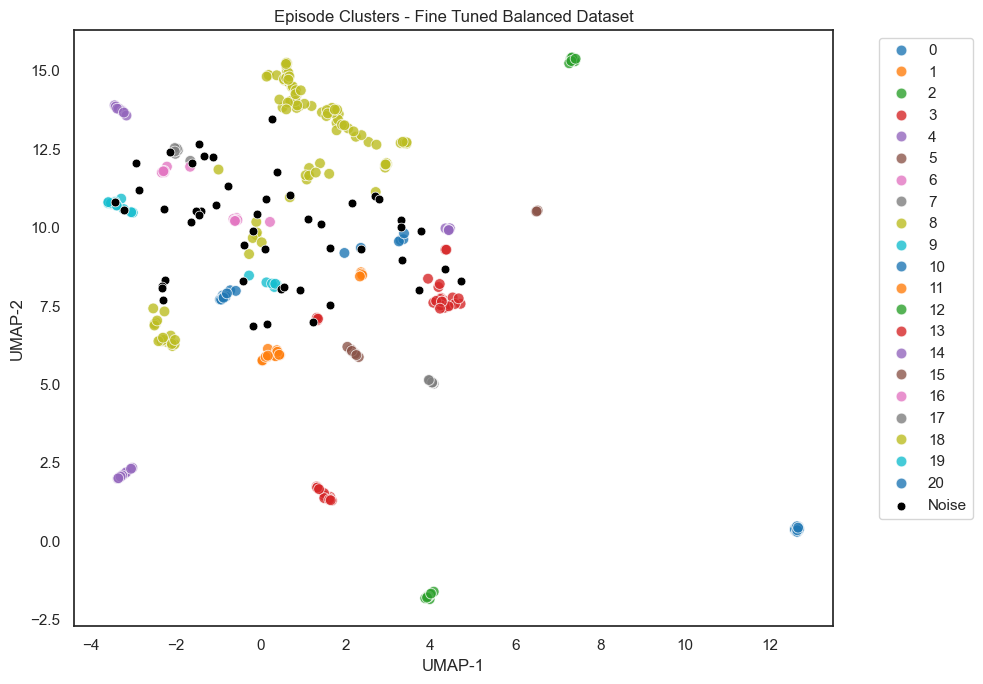

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,7))
plt.style.use('default')
sns.set_theme(style="white", palette="deep")

cluster_idx = np.where(labels != -1)[0]
cluster_sample = np.random.choice(cluster_idx, size=350, replace=False)

noise_idx = np.where(labels == -1)[0]
noise_sample = np.random.choice(noise_idx, size=min(50, len(noise_idx)), replace=False)

final_idx = np.concatenate([cluster_sample, noise_sample])

sns.scatterplot(
    x=embedding_2d[cluster_sample, 0],
    y=embedding_2d[cluster_sample, 1],
    hue=labels[cluster_sample],
    palette="tab10",
    s=60,
    alpha=0.8,
    legend=True
)

sns.scatterplot(
    x=embedding_2d[noise_sample, 0],
    y=embedding_2d[noise_sample, 1],
    color="black",
    s=40,
    label="Noise"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.title("Episode Clusters - Fine Tuned Balanced Dataset")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.tight_layout()
plt.show()

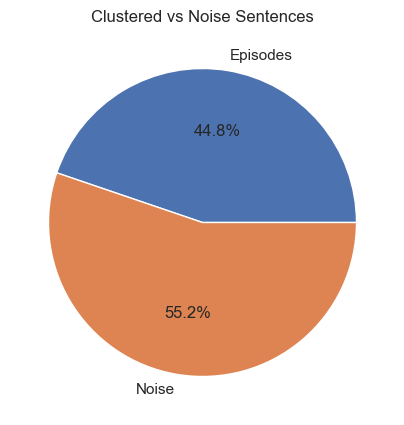

In [60]:
noise = np.sum(labels == -1)
clustered = np.sum(labels != -1)

plt.figure(figsize=(5,5))
plt.pie(
    [clustered, noise],
    labels=["Episodes", "Noise"],
    autopct='%1.1f%%'
)
plt.title("Clustered vs Noise Sentences")
plt.show()

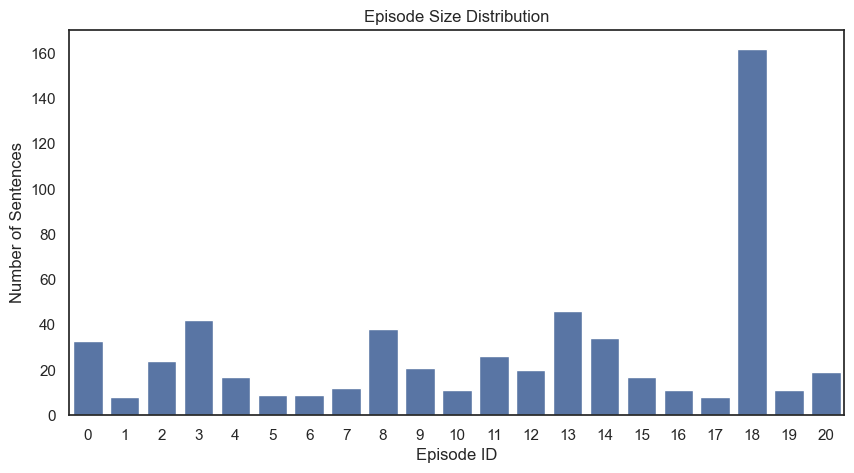

In [61]:
episode_sizes = df[df['episode'] != -1]['episode'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(
    x=episode_sizes.index,
    y=episode_sizes.values
)

plt.title("Episode Size Distribution")
plt.xlabel("Episode ID")
plt.ylabel("Number of Sentences")
plt.show()

In [62]:
t0 = df['timestamp'].min()
df['t'] = (df['timestamp'] - t0).dt.days
df['t_norm'] = df['t'] / df['t'].max()

In [63]:
episode_time_spread = df[df['episode'] != -1].groupby('episode')['t_norm'].std()

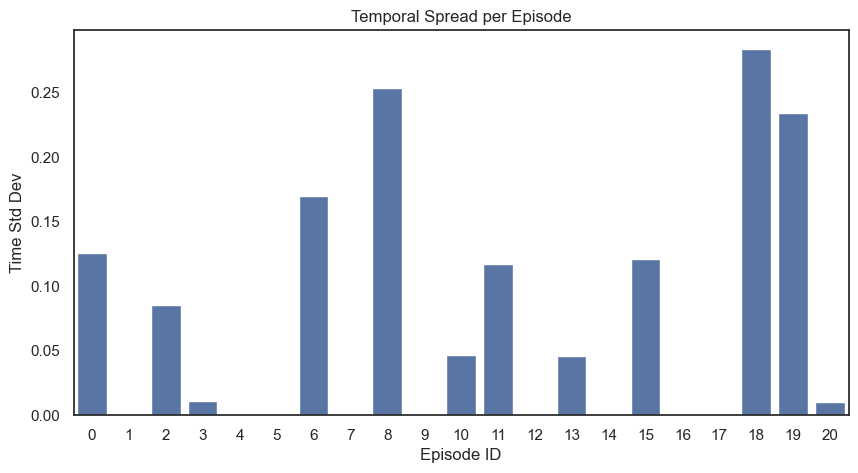

In [64]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=episode_time_spread.index,
    y=episode_time_spread.values
)

plt.title("Temporal Spread per Episode")
plt.xlabel("Episode ID")
plt.ylabel("Time Std Dev")
plt.show()

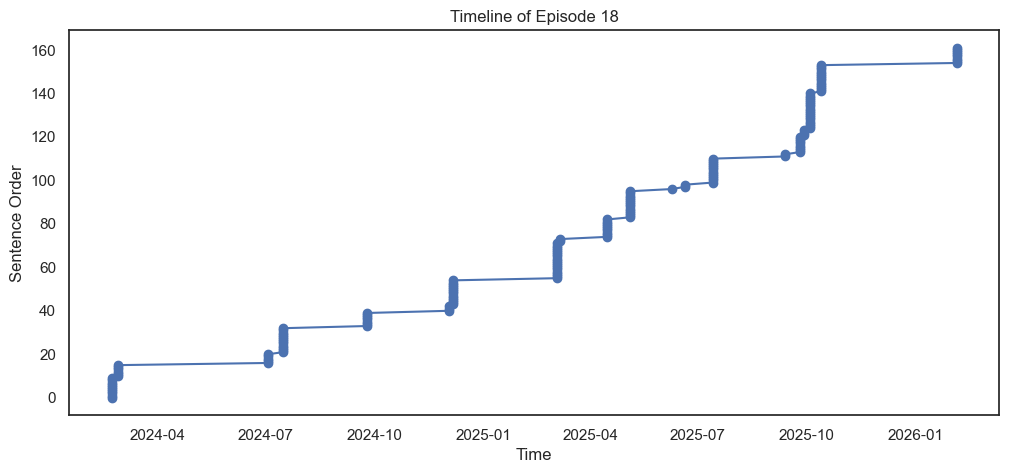

In [65]:
episode_id =18

episode_df = df[df['episode'] == episode_id].sort_values('timestamp')

plt.figure(figsize=(12,5))
plt.plot(episode_df['timestamp'], range(len(episode_df)), marker='o')

plt.title(f"Timeline of Episode {episode_id}")
plt.xlabel("Time")
plt.ylabel("Sentence Order")
plt.show()

## Semantic Coherence Check

In [66]:
sample = df[df['episode'] == episode_id]['sentence'].sample(10, random_state=42)

for s in sample:
    print("-", s)

- According to Tan, the decision to engage with both 5G providers as partners followed a stringent network vendor selection process to ensure the best-suited providers were chosen, with their proven global track record and advanced technologies and solutions being key factors in their selection.
- For example, Lin says 5G will allow hospitals to extend more care to remote areas.
- European operators also facing higher energy bills are struggling to fit costly 5G investment into their financial plans.
- “This collaboration will focus on leveraging advanced 5G and generative AI technologies into real-world business use cases, targeting the retail, manufacturing, logistics, and financial services domains, with the aim of enabling greater innovation for Malaysian enterprises.
- But where greater flexibility, low wireless latency, and high bandwidth are needed, 5G steps in to fill the gap.
- 6G, he said, will force researchers to shift their architecture framework, requiring new memory syst

In [67]:
episode_time = df[df['episode'] == episode_id]['timestamp']

print("Start:", episode_time.min())
print("End:", episode_time.max())

Start: 2024-02-22 00:00:00
End: 2026-02-05 00:00:00


In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = df[df['episode'] == episode_id]['sentence']

vectorizer = TfidfVectorizer(stop_words='english', max_features=10)
X = vectorizer.fit_transform(texts)

print(vectorizer.get_feature_names_out())

['5g' 'advanced' 'areas' 'data' 'malaysia' 'mobile' 'network' 'new' 'said'
 'technology']


In [69]:
from sklearn.metrics.pairwise import cosine_similarity

indices = df[df['episode'] == episode_id].index
cluster_embeddings = embeddings[indices]

sim = cosine_similarity(cluster_embeddings)

print("Average Similarity:", sim.mean())

Average Similarity: 0.8381877268457734


In [70]:
episode_df["orig_index"] = episode_df.index

episode_df[
    ["orig_index", "content_id", "sentence", "published_date", "category", "episode"]
].to_csv(r"dataset\fineTuned\episodes\episode_balanced.csv",index=False)